# Trabajando con clases desbalanceadas

El desbalanceo de clases (o class imbalance) ocurre cuando, en un problema de clasificación, una o más clases están representadas por muchas más observaciones que las otras. En otras palabras, el modelo recibe más ejemplos de una clase (la mayoritaria) que de las otras (las minoritarias), lo que genera un conjunto de datos desequilibrado.

El desbalanceo afecta todas las fases del aprendizaje automático: desde el entrenamiento hasta la evaluación. A continuación, los principales motivos:

- El modelo aprende a “ignorar” la clase minoritaria: La mayoría de los algoritmos de aprendizaje buscan minimizar un error promedio global. Si el 98% de los ejemplos pertenece a una clase, el modelo puede minimizar el error simplemente acertando siempre en esa clase dominante, sin aprender los patrones de la clase minoritaria. En términos simples: El modelo “aprende” que es más rentable equivocarse con pocos casos (los minoritarios) que mejorar su detección, porque eso casi no afecta la métrica global de error.
- Métricas engañosas: En conjuntos desbalanceados, la exactitud (accuracy) deja de ser una medida fiable. Por eso, se deben usar métricas sensibles al desbalance, como precisión, sensibilidad, o f1-score.
- Riesgo de sobreajuste: Cuando se intenta compensar el desbalance repitiendo ejemplos minoritarios (oversampling) o generando ejemplos sintéticos (SMOTE), puede suceder que el modelo memorice patrones específicos de los pocos casos minoritarios, y pierda capacidad de generalizar a nuevos datos.
- Dificulta la validación y el entrenamiento: En validación cruzada, los subconjuntos pueden quedar aún más desbalanceados, afectando las métricas. Algunos modelos, como los árboles o SVM, ajustan los umbrales de decisión según la frecuencia de clases, por lo que predicen mal la clase rara si no se equilibran.


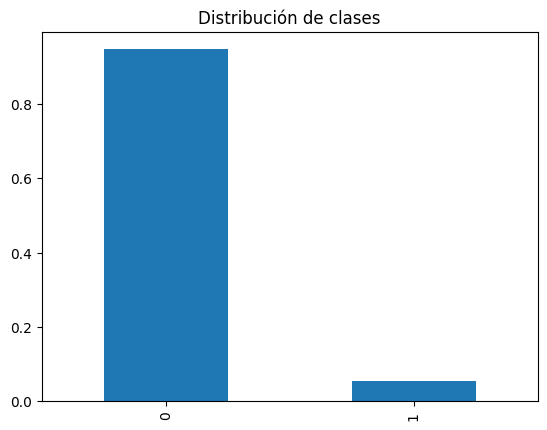

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification

X, y = make_classification(
    n_classes=2,
    weights=[0.95, 0.05],
    n_samples=10000,
    random_state=42,
    n_features=20,
    n_informative=5,
    n_redundant=10
    )

pd.Series(y).value_counts(normalize=True).plot(kind='bar', title='Distribución de clases')
plt.show()

In [2]:
# Extraccion de matrices de caracteristicas y objetivo, y division de los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.8, stratify=y)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (8000, 20)
Tamaño del conjunto de prueba es: (2000, 20)


## Estrategias para trabajar con clases desbalanceadas

| Estrategia               | Descripción                          | Cuándo usar                                   |
| ------------------------ | ------------------------------------ | --------------------------------------------- |
| Ajustar métricas         | Usar F1, Recall, AUC-PR              | Cuando no se puede alterar el dataset         |
| Ponderar clases          | `class_weight='balanced'` en sklearn | Modelos lineales y árboles                    |
| Re-muestrear datos       | Oversampling, Undersampling          | Cuando se dispone de pocos datos minoritarios |
| Generar datos sintéticos | SMOTE, ADASYN                        | Casos de alta escasez o ruido moderado        |


### Ajustar métricas

La primera estrategia a usar consiste en utilizar métricas que sean sensibles al desbalanceo de clases, como *precision*, *recall*, *f1-score* o *average_precision* (AUC-PR). No es recomendable usar *accuracy* o *roc_auc*.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=1)

dist = {
    'max_depth':[3,4,5,6,7,8,9,10],
    'min_samples_split':[2,3,4,5,6,7,8,9,10],
    }

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='accuracy', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.967 with parameters: {'min_samples_split': 8, 'max_depth': 6}
Train score: 0.973
Test score: 0.967


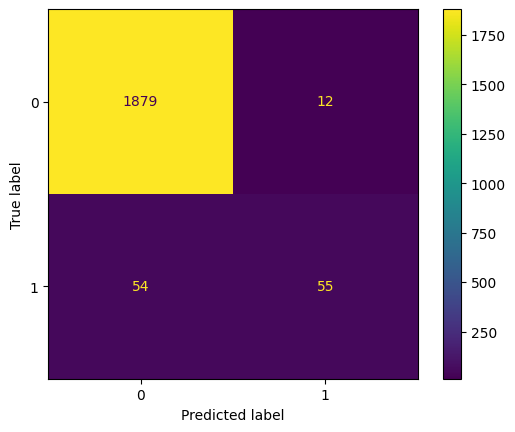

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [5]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1891
           1       0.82      0.50      0.62       109

    accuracy                           0.97      2000
   macro avg       0.90      0.75      0.80      2000
weighted avg       0.96      0.97      0.96      2000



In [6]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='f1', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.627 with parameters: {'min_samples_split': 7, 'max_depth': 10}
Train score: 0.816
Test score: 0.604


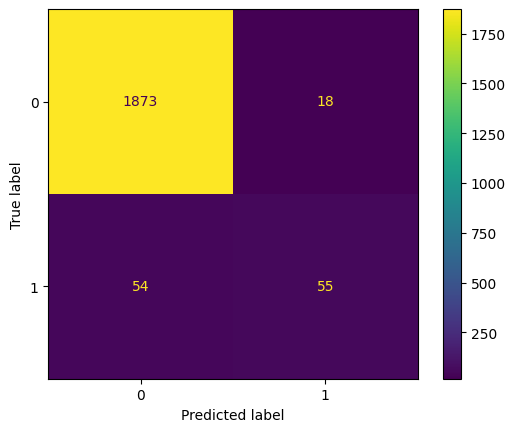

In [7]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [8]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1891
           1       0.75      0.50      0.60       109

    accuracy                           0.96      2000
   macro avg       0.86      0.75      0.79      2000
weighted avg       0.96      0.96      0.96      2000



### Ponderación de clases

En esta estrategia se ajusta el algoritmo de entrenamiento para que los errores en la clase minoritaria “pesen más” durante el cálculo de la función de pérdida. Esto se hace asignando un peso inversamente proporcional a la frecuencia de la clase.

In [9]:
model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=1
    )

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='f1', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.540 with parameters: {'min_samples_split': 3, 'max_depth': 4}
Train score: 0.616
Test score: 0.614


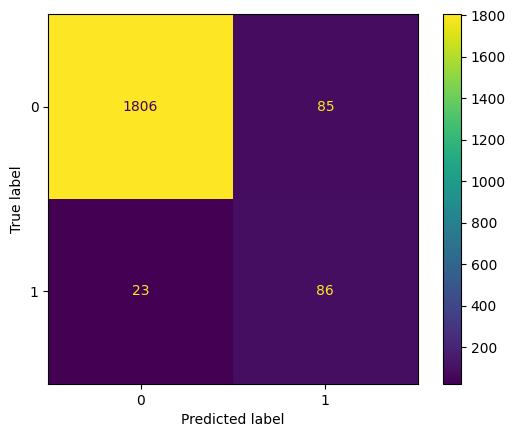

In [10]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [11]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1891
           1       0.50      0.79      0.61       109

    accuracy                           0.95      2000
   macro avg       0.75      0.87      0.79      2000
weighted avg       0.96      0.95      0.95      2000



Es factible modificar los pesos con los que se van a ponderar las clases; de hecho, esto puede ser un hiperparámetro a sintonizar:

In [12]:
dist = {
    'max_depth':[3,4,5,6,7,8,9,10],
    'min_samples_split':[2,3,4],
    'class_weight':['balanced', {0:1, 1:10}, {0:1, 1:20}, {0:1, 1:30}]
    }

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='f1', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.559 with parameters: {'min_samples_split': 4, 'max_depth': 9, 'class_weight': {0: 1, 1: 10}}
Train score: 0.793
Test score: 0.599


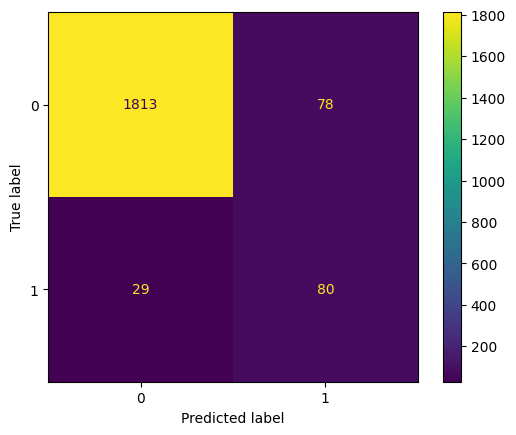

In [13]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [14]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1891
           1       0.51      0.73      0.60       109

    accuracy                           0.95      2000
   macro avg       0.75      0.85      0.79      2000
weighted avg       0.96      0.95      0.95      2000



# Remuestreo de datos

Existen métodos más sofisticados para hacer balanceo de clases, muchos de los cuales están disponibles para su uso en la librería [imblearn](https://imbalanced-learn.org/stable/).

La primera estrategia de este tipo es duplicar instancias minoritarias al azar, lo que se puede hacer con la función `RandomOverSampler`.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

pipe = Pipeline(
    [
        ('sampler', RandomOverSampler(random_state=10)),
        ('model', DecisionTreeClassifier(
            random_state=1
            )
            )
     ]
     )

dist = {
    'model__max_depth':[3,4,5,6,7,8,9,10],
    'model__min_samples_split':[2,3,4],
    }

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='f1', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.528 with parameters: {'model__min_samples_split': 4, 'model__max_depth': 8}
Train score: 0.592
Test score: 0.496


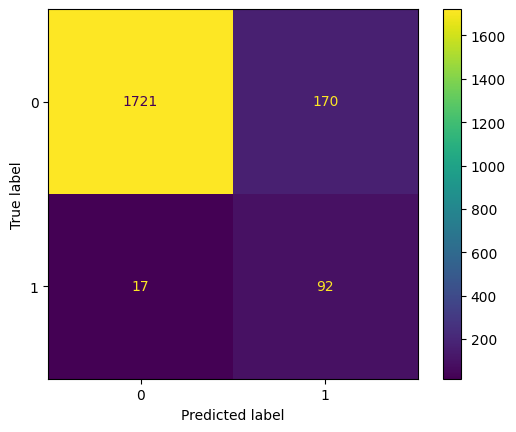

In [16]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [17]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1891
           1       0.35      0.84      0.50       109

    accuracy                           0.91      2000
   macro avg       0.67      0.88      0.72      2000
weighted avg       0.96      0.91      0.92      2000



También se puede submuestrear la clase mayoritaria:

In [18]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

pipe = Pipeline(
    [
        ('sampler', RandomUnderSampler(random_state=10)),
        ('model', DecisionTreeClassifier(
            random_state=1
            )
            )
     ]
     )

dist = {
    'model__max_depth':[3,4,5,6,7,8,9,10],
    'model__min_samples_split':[2,3,4],
    }

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='f1', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.425 with parameters: {'model__min_samples_split': 2, 'model__max_depth': 4}
Train score: 0.362
Test score: 0.373


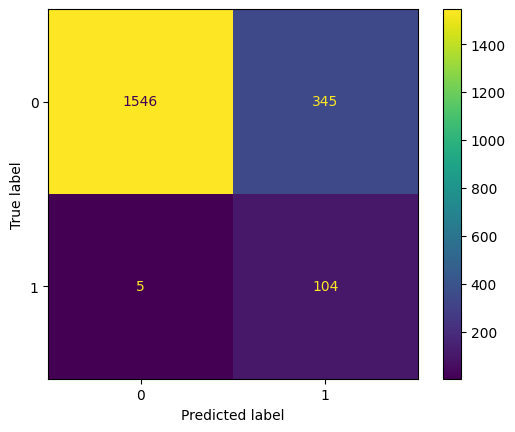

In [19]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [20]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90      1891
           1       0.23      0.95      0.37       109

    accuracy                           0.82      2000
   macro avg       0.61      0.89      0.64      2000
weighted avg       0.96      0.82      0.87      2000



### Generación de datos sintéticos

Existen técnicas como SMOTE (Synthetic Minority Over-sampling Technique) para crear datos sintéticos. Esta método fue propuesto por Chawla et al. (2002) como una mejora sobre el simple duplicado de ejemplos minoritarios (oversampling aleatorio). Su propósito es equilibrar el conjunto de datos creando nuevas instancias sintéticas de la clase minoritaria —no copias—, generadas a partir de los datos existentes. En esencia, funciona así:

1. Selecciona un ejemplo minoritario.
2. Encuentra sus k vecinos más cercanos; por defecto $k=5$.
3. Selecciona al azar uno de esos vecinos, y crea una nueva muestra sintética a una distancia aleatoria $\lambda$ de ese vecino.


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pipe = Pipeline(
    [
        ('sampler', SMOTE(k_neighbors=5, random_state=10)),
        ('model', DecisionTreeClassifier(
            random_state=1
            )
            )
     ]
     )

dist = {
    'model__max_depth':[3,4,5,6,7,8,9,10],
    'model__min_samples_split':[2,3,4],
    'sampler__k_neighbors':[5,6,7]
    }

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=dist,
    n_jobs=-1, # Usar todos los núcleos disponibles
    scoring='f1', # Métrica de evaluación
    random_state=1,
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.501 with parameters: {'sampler__k_neighbors': 5, 'model__min_samples_split': 3, 'model__max_depth': 7}
Train score: 0.584
Test score: 0.520


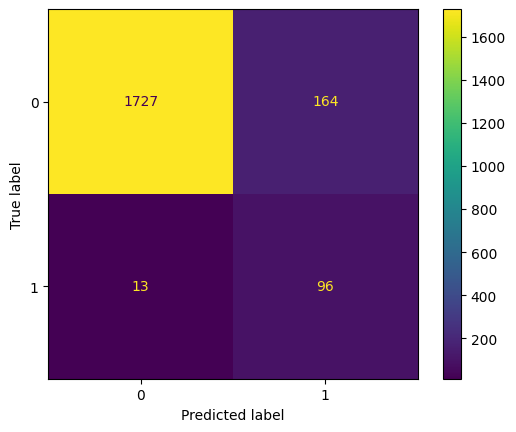

In [22]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test);

In [23]:
print(classification_report(y_test, random_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1891
           1       0.37      0.88      0.52       109

    accuracy                           0.91      2000
   macro avg       0.68      0.90      0.74      2000
weighted avg       0.96      0.91      0.93      2000

